# 03 · The `run_python` tool, used by hand

The agent (notebook 04, Pydantic AI) will get these 4 plain functions as tools. Here I call them myself, once per
functionality, and look at exactly the text the LLM will see. Requires the image from notebook 02.

* `run_python(code)` — the sandbox `exec` endpoint; starts the conversation's container if it is not running
* `kernel_state()` — `state`
* `reset_kernel()` — `reset`
* `describe_environment()` — `env` (goes into the system prompt)

In [1]:
import json, sys, time
from pathlib import Path
from IPython.display import Image, display

sys.path.insert(0, "../sandbox")
import sandbox as sb

CONVERSATION_ID = "conv_001"          # the harness will set this per conversation

## 1 · Tool definitions (docstrings = tool descriptions)

In [2]:
def run_python(code: str, timeout: int = 60) -> str:
    """Run Python code in this conversation's sandbox and return what happened.
    Pre-imported: numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns.
    DATA = path of the AERONET AOD Level 2 daily parquet (read-only; read a column subset, the full table is ~1 GB).
    Variables persist between calls. Open matplotlib figures are saved as PNG automatically.
    Write any export (parquet, csv, png) under /workspace/. No network. 2 GB RAM, 2 CPUs.
    The value of the last expression is returned as a preview, like in a notebook."""
    if not sb.running(CONVERSATION_ID):
        sb.start(CONVERSATION_ID)
    r = sb.exec_code(CONVERSATION_ID, code, timeout)
    out = []
    if r.get("stdout"):       out.append(r["stdout"].rstrip())
    if r.get("stderr"):       out.append("stderr:\n" + r["stderr"].rstrip())
    if r.get("error"):        out.append("ERROR: " + r["error"])
    if r.get("result"):       out.append(r["result"])
    if r.get("figures"):      out.append("figures saved: " + ", ".join(r["figures"]))
    if r.get("new_files"):    out.append("files written: " + ", ".join(r["new_files"]))
    if r.get("vars_new"):     out.append(f"new variables: {r['vars_new']}")
    if r.get("vars_changed"): out.append(f"changed variables: {r['vars_changed']}")
    if "elapsed_s" in r:      out.append(f"[{r['elapsed_s']} s, {r['rss_mb']} MB RSS]")
    return "\n".join(out)

def kernel_state() -> str:
    """Variables (type and shape), files in /workspace and memory use of this conversation's sandbox."""
    return json.dumps(sb.state(CONVERSATION_ID), indent=1)

def reset_kernel() -> str:
    """Delete all variables and open figures. Files in /workspace are kept."""
    sb.reset(CONVERSATION_ID)
    return "kernel reset: no variables"

def describe_environment() -> str:
    """Python and package versions, limits and pre-imported names of the sandbox."""
    return json.dumps(sb.env(CONVERSATION_ID), indent=1)


# notebook only: display the PNGs a run_python call mentions
def show_figures(text: str):                   
    for line in text.splitlines():
        if line.startswith("figures saved: "):
            for f in line[len("figures saved: "):].split(", "):
                display(Image(sb.CONV_DIR / CONVERSATION_ID / f))

## 2 · `describe_environment`

In [3]:
sb.start(CONVERSATION_ID)
print(describe_environment())

{
 "python": "3.13.15",
 "packages": {
  "numpy": "2.2.2",
  "pandas": "2.2.3",
  "pyarrow": "24.0.0",
  "matplotlib": "3.11.2",
  "seaborn": "0.13.2",
  "ipython": "9.17.1"
 },
 "memory_limit_mb": 2147,
 "cpus": 2.0,
 "workspace_cap_gb": 1.0,
 "data": "/data/aeronet.parquet",
 "preloaded": "import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns\nDATA = \"/data/aeronet.parquet\"   # AERONET AOD L2 daily table (read-only)"
}


In [5]:
!docker ps --filter name=conv_001

CONTAINER ID   IMAGE             COMMAND                  CREATED          STATUS          PORTS     NAMES
cde0493c1d8b   aeronet-sandbox   "python /exec_server…"   19 seconds ago   Up 18 seconds             conv_001


## 3 · `run_python`: print, last-expression preview, new variables

In [6]:
print(run_python("""
rng = np.random.default_rng(42)
n = 500
df = pd.DataFrame({"site": rng.choice(["Banizoumbou", "GSFC", "Kanpur"], n),
                   "aod_500": rng.lognormal(-1.2, 0.7, n),
                   "ae_440_870": rng.normal(1.2, 0.5, n)})
print(df.shape)
df.groupby("site")[["aod_500", "ae_440_870"]].agg(["mean", "std"]).round(3)
"""))

(500, 3)
DataFrame (3, 4)
dtypes:
aod_500     mean    float64
            std     float64
ae_440_870  mean    float64
            std     float64

head:
            aod_500        ae_440_870       
               mean    std       mean    std
site                                        
Banizoumbou   0.379  0.304      1.231  0.497
GSFC          0.345  0.236      1.200  0.464
Kanpur        0.400  0.327      1.174  0.530

tail:
            aod_500        ae_440_870       
               mean    std       mean    std
site                                        
Banizoumbou   0.379  0.304      1.231  0.497
GSFC          0.345  0.236      1.200  0.464
Kanpur        0.400  0.327      1.174  0.530
new variables: {'rng': 'Generator', 'n': 'int', 'df': 'DataFrame(500, 3)'}
[0.035 s, 154 MB RSS]


In [14]:
sb.state(CONVERSATION_ID)

{'vars': {'rng': 'Generator',
  'n': 'int',
  'df': 'DataFrame(500, 3)',
  'g': 'FacetGrid'},
 'files': ['fig_001.png', 'random_sites.parquet'],
 'workspace_mb': 0,
 'workspace_cap_mb': 1000,
 'rss_mb': 170}

In [9]:
sb.env(CONVERSATION_ID)

{'python': '3.13.15',
 'packages': {'numpy': '2.2.2',
  'pandas': '2.2.3',
  'pyarrow': '24.0.0',
  'matplotlib': '3.11.2',
  'seaborn': '0.13.2',
  'ipython': '9.17.1'},
 'memory_limit_mb': 2147,
 'cpus': 2.0,
 'workspace_cap_gb': 1.0,
 'data': '/data/aeronet.parquet',
 'preloaded': 'import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns\nDATA = "/data/aeronet.parquet"   # AERONET AOD L2 daily table (read-only)'}

### variables persist between calls; figures are saved automatically

In [10]:
text = run_python("""
g = sns.FacetGrid(df, col="site", height=3)
g.map_dataframe(sns.histplot, x="aod_500", bins=25)
df.to_parquet("/workspace/random_sites.parquet")
""")
print(text)

figures saved: fig_001.png
files written: random_sites.parquet
new variables: {'g': 'FacetGrid'}
[0.646 s, 170 MB RSS]


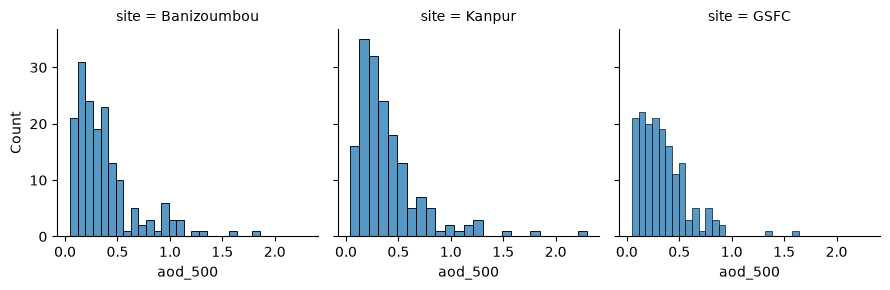

In [11]:
show_figures(text)

In [15]:
sb.state(CONVERSATION_ID)

{'vars': {'rng': 'Generator',
  'n': 'int',
  'df': 'DataFrame(500, 3)',
  'g': 'FacetGrid'},
 'files': ['fig_001.png', 'random_sites.parquet'],
 'workspace_mb': 0,
 'workspace_cap_mb': 1000,
 'rss_mb': 170}

### the real AERONET data over the read-only mount

In [27]:
text = run_python("""
cols = ["AERONET_Site_Name", "date", "year", "AOD_500nm"]
kanpur = pd.read_parquet(DATA, columns=cols, filters=[("AERONET_Site_Name", "==", "Kanpur")])
yearly = kanpur.groupby("year")["AOD_500nm"].agg(["mean", "count"])
yearly[yearly["count"] >= 100].plot(y="mean", marker="o", title="Kanpur yearly mean AOD 500 nm", figsize=(8, 3))
yearly.to_csv("/workspace/kanpur_yearly_aod500.csv")
yearly
""")

DataFrame (25, 2)
dtypes:
mean     float64
count      int64

head:
          mean  count
year                 
2001  0.560723    255
2002  0.606424    272
2003  0.677890    208
2004  0.641306    180
2005  0.600092    293

tail:
          mean  count
year                 
2021  0.712734    262
2022  0.720913    292
2023  0.594883    204
2024  0.725229    215
2025  0.677934    139
figures saved: fig_002.png
changed variables: {'cols': 'list', 'kanpur': 'DataFrame(5728, 4)', 'yearly': 'DataFrame(25, 2)'}
[0.247 s, 270 MB RSS]


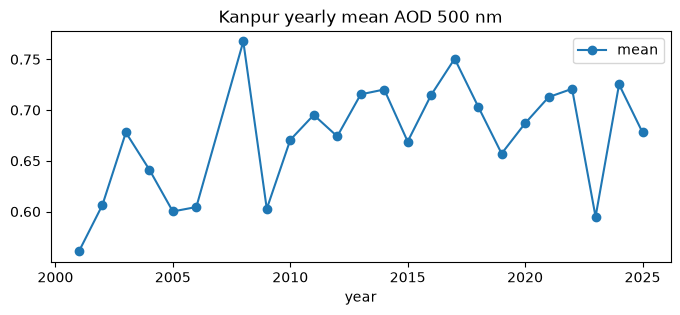

In [28]:
print(text)
show_figures(text)

In [30]:
print(text)

DataFrame (25, 2)
dtypes:
mean     float64
count      int64

head:
          mean  count
year                 
2001  0.560723    255
2002  0.606424    272
2003  0.677890    208
2004  0.641306    180
2005  0.600092    293

tail:
          mean  count
year                 
2021  0.712734    262
2022  0.720913    292
2023  0.594883    204
2024  0.725229    215
2025  0.677934    139
figures saved: fig_002.png
changed variables: {'cols': 'list', 'kanpur': 'DataFrame(5728, 4)', 'yearly': 'DataFrame(25, 2)'}
[0.247 s, 270 MB RSS]


### errors come back as text, the shell survives

In [18]:
print(run_python("df['no_such_column'].mean()"))

---------------------------------------------------------------------------
KeyError                                  Traceback (most recent call last)
File /usr/local/lib/python3.13/site-packages/pandas/core/indexes/base.py:3805, in Index.get_loc(self, key)
   3804 try:
-> 3805     return self._engine.get_loc(casted_key)
   3806 except KeyError as err:

File index.pyx:167, in pandas._libs.index.IndexEngine.get_loc()
--> 167 'Could not get source, probably due dynamically evaluated source code.'
File index.pyx:196, in pandas._libs.index.IndexEngine.get_loc()
--> 196 'Could not get source, probably due dynamically evaluated source code.'
File pandas/_libs/hashtable_class_helper.pxi:7081, in pandas._libs.hashtable.PyObjectHashTable.get_item()
-> 7081 'Could not get source, probably due dynamically evaluated source code.'
File pandas/_libs/hashtable_class_helper.pxi:7089, in pandas._libs.hashtable.PyObjectHashTable.get_item()
-> 7089 'Could not get source, probably due dynamically evaluat

### timeout

In [19]:
print(run_python("import time; time.sleep(30)", timeout=3))
print(run_python("len(df)"))            # still alive, df still there

---------------------------------------------------------------------------
TimeoutError                              Traceback (most recent call last)
Cell In[5], line 1
----> 1 import time; time.sleep(30)

File /exec_server.py:106, in _timeout(signum, frame)
    105 def _timeout(signum, frame):
--> 106     raise TimeoutError("cell exceeded its timeout")

TimeoutError: cell exceeded its timeout
ERROR: TimeoutError('cell exceeded its timeout')
new variables: {'time': 'module'}
[3.021 s, 282 MB RSS]
500
[0.002 s, 282 MB RSS]


## 4 · `kernel_state`

In [20]:
print(kernel_state())

{
 "vars": {
  "rng": "Generator",
  "n": "int",
  "df": "DataFrame(500, 3)",
  "g": "FacetGrid",
  "cols": "list",
  "kanpur": "DataFrame(5728, 4)",
  "yearly": "DataFrame(25, 2)",
  "time": "module"
 },
 "files": [
  "fig_001.png",
  "fig_002.png",
  "kanpur_yearly_aod500.csv",
  "random_sites.parquet"
 ],
 "workspace_mb": 0,
 "workspace_cap_mb": 1000,
 "rss_mb": 282
}


## 5 · `reset_kernel`

In [21]:
print(reset_kernel())
print(kernel_state())
print(run_python("df"))                 # NameError: gone

kernel reset: no variables
{
 "vars": {},
 "files": [
  "fig_001.png",
  "fig_002.png",
  "kanpur_yearly_aod500.csv",
  "random_sites.parquet"
 ],
 "workspace_mb": 0,
 "workspace_cap_mb": 1000,
 "rss_mb": 282
}
---------------------------------------------------------------------------
NameError                                 Traceback (most recent call last)
Cell In[7], line 1
----> 1 df

NameError: name 'df' is not defined
ERROR: NameError("name 'df' is not defined")
[0.006 s, 282 MB RSS]


## 6 · Container dies (memory limit, storage cap or idle stop) → the agent is told why, and the next `run_python` starts a fresh one on the same folder

In [22]:
print(run_python("x = np.ones(3_000_000_000, dtype=np.uint8)"))     # > 2 GB
print("running:", sb.running(CONVERSATION_ID))
print(run_python("print('back'); DATA"))
print(kernel_state())                                                 # files kept, variables empty

ERROR: sandbox 'conv_001' is not running: killed by the memory limit. All variables are lost, files are kept. start('conv_001') gives a fresh sandbox.
running: False
back
'/data/aeronet.parquet'
[0.003 s, 151 MB RSS]
{
 "vars": {},
 "files": [
  "fig_001.png",
  "fig_002.png",
  "kanpur_yearly_aod500.csv",
  "random_sites.parquet"
 ],
 "workspace_mb": 0,
 "workspace_cap_mb": 1000,
 "rss_mb": 151
}


## 7 · Everything the conversation exported, seen from the host (`conversation_data/conv_001/`, gitignored)

In [31]:
sorted(p.name for p in (sb.CONV_DIR / CONVERSATION_ID).iterdir())

['exec.sock',
 'fig_001.png',
 'fig_002.png',
 'kanpur_yearly_aod500.csv',
 'random_sites.parquet']

## 8 · Cleanup (the container would otherwise remove itself after 60 idle minutes)

In [32]:
sb.stop(CONVERSATION_ID)
!docker ps --filter name=conv_001

CONTAINER ID   IMAGE     COMMAND   CREATED   STATUS    PORTS     NAMES
